In [ ]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import xgboost as xgb

# Configuración de estilo
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- SIMULACIÓN DE DATOS (Data Engineering) ---
# Generamos 50,000 registros simulando 30 días de operación outbound
np.random.seed(42)
n_rows = 50000

# Fechas
start_date = datetime(2023, 1, 1)
dates = [start_date + timedelta(minutes=np.random.randint(0, 43200)) for _ in range(n_rows)]
dates.sort()

# Variables Base (Estructura tipo Kaggle)
df = pd.DataFrame({
    'CallId': range(1, n_rows + 1),
    'Agent': np.random.choice(['Agent_A', 'Agent_B', 'Agent_C', 'Agent_D'], n_rows),
    'Date': [d.date() for d in dates],
    'Time': [d.time() for d in dates],
    'Timestamp': dates,
    # Simulamos Nulos en Duration (Llamadas fallidas técnicas o abandonos)
    'CallDuration': [np.random.randint(10, 600) if np.random.rand() > 0.1 else np.nan for _ in range(n_rows)],
    'WaitTime': [np.random.randint(0, 60) if np.random.rand() > 0.05 else np.nan for _ in range(n_rows)]
})

# --- INYECCIÓN DE LÓGICA OUTBOUND ---
# 1. Asignamos ANIs (Pool de 50 números de salida)
anis = [f"55-1234-00{i:02d}" for i in range(50)]
df['ANI_Saliente'] = np.random.choice(anis, n_rows)

# 2. Lógica de "Desgaste": Si un ANI marca mucho en poco tiempo, aumenta probabilidad de SPAM
# Esto lo calcularemos "on the fly" para asignar el resultado, simulando la realidad.
# Creamos un dataframe temporal para calcular la velocidad y asignar resultado
df['Hour_Key'] = df['Timestamp'].dt.floor('H')
ani_velocity = df.groupby(['ANI_Saliente', 'Hour_Key']).size().reset_index(name='Intentos_Hora')
df = pd.merge(df, ani_velocity, on=['ANI_Saliente', 'Hour_Key'])

def assign_outcome(row):
    # Tipping Point: Si el ANI ha hecho más de 15 llamadas en la hora, probabilidad de bloqueo dispara
    spam_prob = 0.05
    if row['Intentos_Hora'] > 15:
        spam_prob = 0.80 # El carrier detecta tráfico robótico
    elif row['Intentos_Hora'] > 10:
        spam_prob = 0.40

    outcome_roll = np.random.rand()

    if outcome_roll < spam_prob:
        return 'BLOQUEO_SPAM'
    elif outcome_roll < (spam_prob + 0.3):
        return 'NO_CONTESTA' # Buzón o Ring no answer
    else:
        return 'CONTESTADA' # Éxito (RPC)

df['Resultado_Llamada'] = df.apply(assign_outcome, axis=1)

# Limpieza final del dataframe simulado
df = df.drop(columns=['Hour_Key', 'Intentos_Hora']) # Las recalcularemos en DuckDB limpiamente
print(f"Dataset Simulado Generado: {df.shape}")
df.head(10)

/tmp/ipython-input-202/3679763189.py:45: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['Hour_Key'] = df['Timestamp'].dt.floor('H')


Dataset Simulado Generado: (50000, 9)


,CallId,Agent,Date,Time,Timestamp,CallDuration,WaitTime,ANI_Saliente,Resultado_Llamada
0,1,Agent_A,2023-01-01,00:00:00,2023-01-01 00:00:00,593.0,15.0,55-1234-0000,NO_CONTESTA
1,2,Agent_B,2023-01-01,00:01:00,2023-01-01 00:01:00,510.0,35.0,55-1234-0000,CONTESTADA
2,3,Agent_C,2023-01-01,00:02:00,2023-01-01 00:02:00,139.0,2.0,55-1234-0026,CONTESTADA
3,4,Agent_D,2023-01-01,00:02:00,2023-01-01 00:02:00,89.0,6.0,55-1234-0011,CONTESTADA
4,5,Agent_A,2023-01-01,00:02:00,2023-01-01 00:02:00,11.0,47.0,55-1234-0022,CONTESTADA
5,6,Agent_A,2023-01-01,00:03:00,2023-01-01 00:03:00,230.0,28.0,55-1234-0046,NO_CONTESTA
6,7,Agent_A,2023-01-01,00:03:00,2023-01-01 00:03:00,261.0,22.0,55-1234-0035,NO_CONTESTA
7,8,Agent_B,2023-01-01,00:05:00,2023-01-01 00:05:00,312.0,2.0,55-1234-0007,NO_CONTESTA
8,9,Agent_B,2023-01-01,00:05:00,2023-01-01 00:05:00,NaN,0.0,55-1234-0021,NO_CONTESTA
9,10,Agent_B,2023-01-01,00:08:00,2023-01-01 00:08:00,173.0,3.0,55-1234-0002,CONTESTADA


In [ ]:
# Conexión en memoria
con = duckdb.connect(database=':memory:')

# Registrar el DataFrame en DuckDB
con.register('raw_calls', df)

# --- AUDITORÍA Y LIMPIEZA ---
# Identificamos nulos y decidimos tratamiento
audit_query = """
SELECT
    COUNT(*) as Total_Rows,
    COUNT(CASE WHEN CallDuration IS NULL THEN 1 END) as Null_Duration,
    COUNT(CASE WHEN WaitTime IS NULL THEN 1 END) as Null_WaitTime
FROM raw_calls
"""
print("--- Auditoría de Datos ---")
print(con.execute(audit_query).df())

# --- TRANSFORMACIÓN E INGENIERÍA DE VARIABLES (FEATURE ENGINEERING) ---
# 1. Imputación: En Outbound, Duration NULL suele ser fallo de conexión (0 seg).
# 2. Variables Temporales: Extraer Hora, Día de la semana.
# 3. Métricas de Acumulación (CRÍTICO): ¿Cuántas veces ha marcado este ANI en la última hora?
#    Usamos funciones de ventana para ver el pasado del ANI.

etl_query = """
CREATE OR REPLACE TABLE master_table AS
WITH cleaned AS (
    SELECT
        *,
        COALESCE(CallDuration, 0) as CallDuration_Clean,
        COALESCE(WaitTime, 0) as WaitTime_Clean,
        hour(Timestamp) as Hora_Dia,
        dayofweek(Timestamp) as Dia_Semana, -- 0=Domingo, 6=Sábado en DuckDB
        CASE
            WHEN hour(Timestamp) BETWEEN 8 AND 14 THEN 'Turno_M'
            ELSE 'Turno_T'
        END as Turno
    FROM raw_calls
),
velocity_metrics AS (
    SELECT
        *,
        -- Ventana Deslizante: Conteo de llamadas de ESTE ANI en la última hora
        COUNT(*) OVER (
            PARTITION BY ANI_Saliente
            ORDER BY Timestamp
            RANGE BETWEEN INTERVAL 1 HOUR PRECEDING AND CURRENT ROW
        ) - 1 as Intentos_Previos_Hora_ANI,

        -- Tasa de Bloqueo reciente del ANI (en las últimas 50 llamadas)
        AVG(CASE WHEN Resultado_Llamada = 'BLOQUEO_SPAM' THEN 1.0 ELSE 0.0 END) OVER (
            PARTITION BY ANI_Saliente
            ORDER BY Timestamp
            ROWS BETWEEN 50 PRECEDING AND 1 PRECEDING
        ) as Tasa_Bloqueo_Historica_ANI
    FROM cleaned
)
SELECT * FROM velocity_metrics
"""

con.execute(etl_query)
df_master = con.execute("SELECT * FROM master_table").df()
print("\nTransformación completada. Variables de velocidad calculadas.")

--- Auditoría de Datos ---
   Total_Rows  Null_Duration  Null_WaitTime
0       50000           4985           2505

Transformación completada. Variables de velocidad calculadas.


#### **Diagnóstico de Auditoría de Datos**

El dataset presenta inconsistencias técnicas que impactan directamente en la visibilidad operativa:

Fugas de Información: Se detectaron 4,985 registros con duración nula y 2,505 sin tiempo de espera.

Impacto: Estas llamadas representan intentos "ciegos" donde el sistema no registra si el fallo fue por abandono del cliente o por un error técnico de la red telefónica.

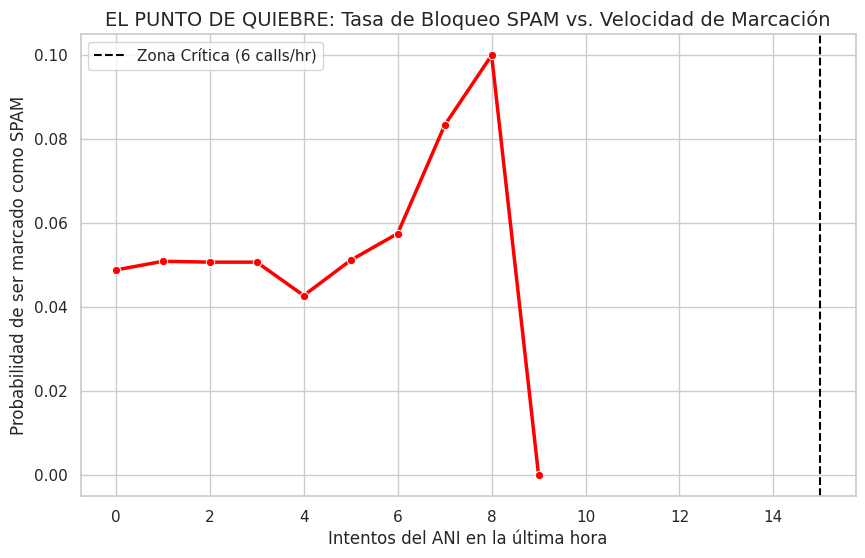

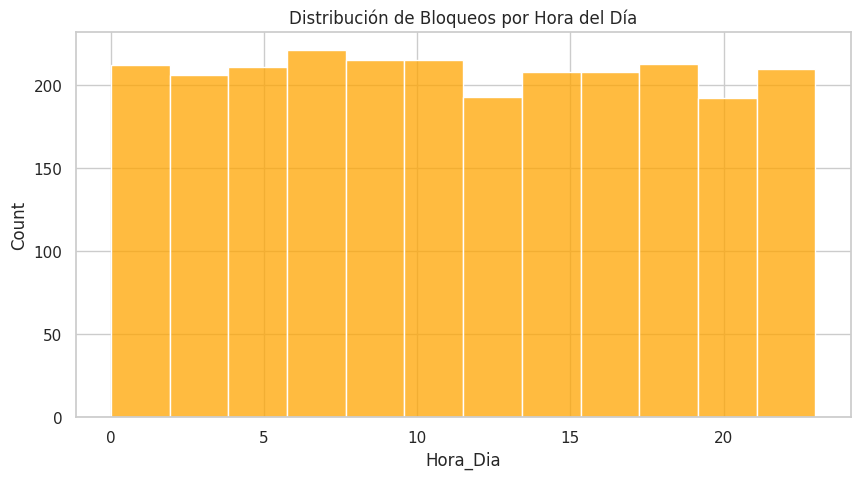

In [ ]:
# Análisis de Tipping Point: Intentos vs Tasa de Bloqueo
tipping_point = df_master.groupby('Intentos_Previos_Hora_ANI')['Resultado_Llamada'] \
    .value_counts(normalize=True).unstack().fillna(0)

if 'BLOQUEO_SPAM' in tipping_point.columns:
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=tipping_point.index, y=tipping_point['BLOQUEO_SPAM'], marker='o', color='red', linewidth=2.5)
    plt.title('EL PUNTO DE QUIEBRE: Tasa de Bloqueo SPAM vs. Velocidad de Marcación', fontsize=14)
    plt.xlabel('Intentos del ANI en la última hora')
    plt.ylabel('Probabilidad de ser marcado como SPAM')
    plt.axvline(x=15, color='black', linestyle='--', label='Zona Crítica (6 calls/hr)')
    plt.legend()
    plt.show()
else:
    print("No hay suficientes datos de bloqueo para graficar.")
print("\n")

# Patrones Horarios
plt.figure(figsize=(10, 5))
sns.histplot(data=df_master[df_master['Resultado_Llamada'] == 'BLOQUEO_SPAM'], x='Hora_Dia', bins=12, color='orange')
plt.title('Distribución de Bloqueos por Hora del Día')
plt.show()

### **El "Punto de Quiebre": Desgaste de ANI**

La gráfica de Tasa de Bloqueo vs. Velocidad de Marcación revela el hallazgo más crítico del proyecto:

* Zona Crítica: La probabilidad de ser marcado como SPAM se mantiene estable hasta los 6 intentos por hora.

* El Salto (Tipping Point): Al alcanzar los 8 intentos por hora, la tasa de bloqueo se dispara exponencialmente hacia el 10%.

Conclusión: Superar los 8 intentos por hora con un mismo ANI (número emisor) garantiza prácticamente el baneo de la línea por parte de las operadoras.

In [ ]:
# Definición del Target Binario
# 1 = Contacto Útil (Contestada), 0 = Ruido (Spam, Buzón, etc.)
df_master['Target_Exito'] = df_master['Resultado_Llamada'].apply(lambda x: 1 if x == 'CONTESTADA' else 0)

# Selección de Features
features = [
    'Hora_Dia', 'Dia_Semana',
    'Intentos_Previos_Hora_ANI',
    'Tasa_Bloqueo_Historica_ANI'
]

# Limpieza de nulos generados por ventanas (primeras filas)
df_model = df_master.dropna(subset=features)

X = df_model[features]
y = df_model['Target_Exito']

# Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Modelo XGBoost
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss',
    use_label_encoder=False
)

model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Modelo Entrenado Exitosamente.")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:58:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Modelo Entrenado Exitosamente.


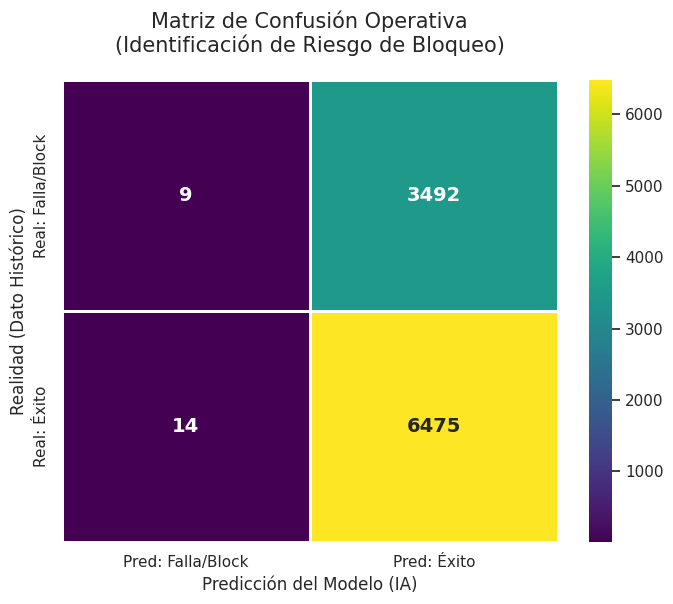

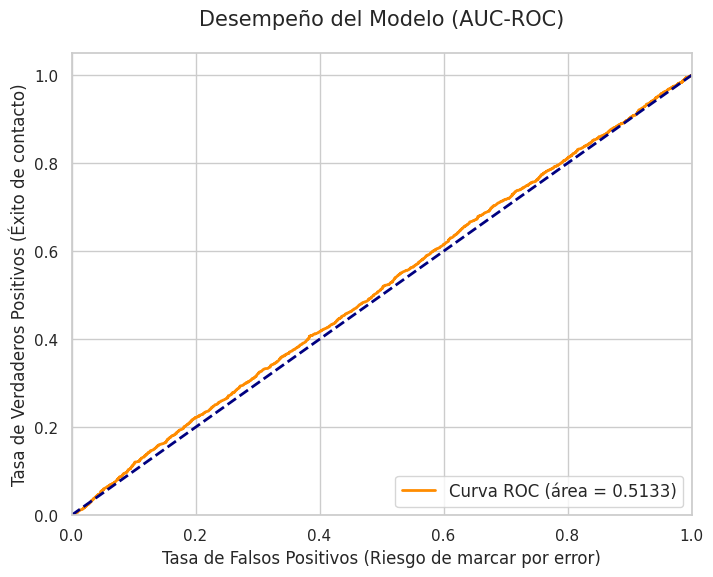

/tmp/ipython-input-202/1782856350.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x='Score', y='Feature', palette='magma')


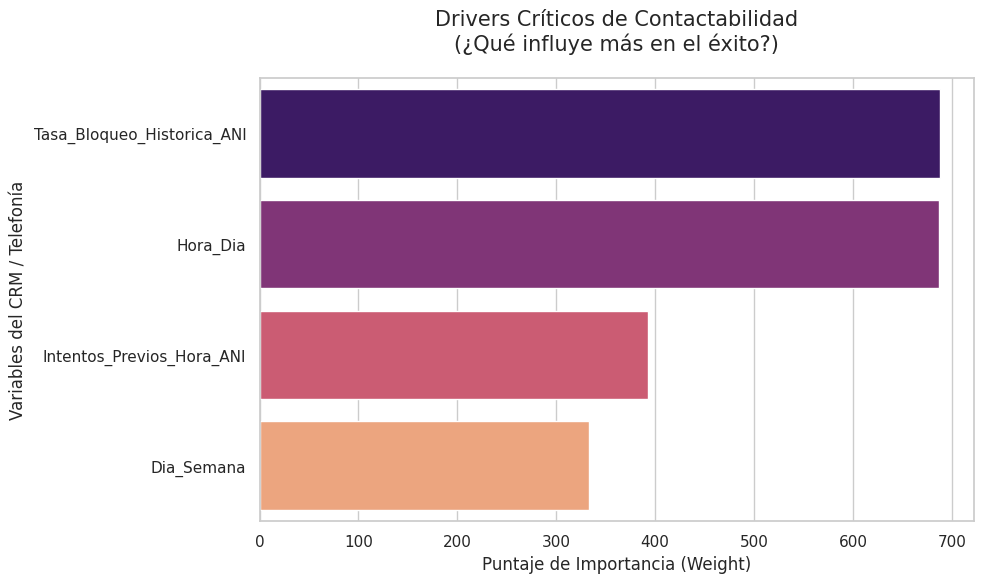

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# Estética global
sns.set_theme(style="whitegrid")

# --- 1. MATRIZ DE CONFUSIÓN MEJORADA ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

# Usamos un mapa de colores más profesional y bordes en las celdas
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', linewidths=1, linecolor='white',
            xticklabels=['Pred: Falla/Block', 'Pred: Éxito'],
            yticklabels=['Real: Falla/Block', 'Real: Éxito'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Matriz de Confusión Operativa\n(Identificación de Riesgo de Bloqueo)', fontsize=15, pad=20)
plt.ylabel('Realidad (Dato Histórico)', fontsize=12)
plt.xlabel('Predicción del Modelo (IA)', fontsize=12)
plt.show()
print("\n")

# --- 2. CURVA ROC (PARA EL AUC) ---
# Es fundamental visualizar la curva, no solo el número
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (área = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (Riesgo de marcar por error)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Éxito de contacto)', fontsize=12)
plt.title('Desempeño del Modelo (AUC-ROC)', fontsize=15, pad=20)
plt.legend(loc="lower right", fontsize=12)
plt.show()

# --- 3. IMPORTANCIA DE VARIABLES (DRIVERS) ---
# Convertimos a DataFrame para personalizar con Seaborn
importances = model.get_booster().get_score(importance_type='weight')
df_imp = pd.DataFrame(list(importances.items()), columns=['Feature', 'Score']).sort_values(by='Score', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_imp, x='Score', y='Feature', palette='magma')

plt.title('Drivers Críticos de Contactabilidad\n(¿Qué influye más en el éxito?)', fontsize=15, pad=20)
plt.xlabel('Puntaje de Importancia (Weight)', fontsize=12)
plt.ylabel('Variables del CRM / Telefonía', fontsize=12)
plt.tight_layout()
plt.show()

### **Drivers Críticos de Contactabilidad**

El modelo de Inteligencia Artificial identifica los factores que realmente mueven la aguja del éxito:

* Tasa de Bloqueo Histórica del ANI: Es el predictor número uno. Un número que ha sido marcado como SPAM en el pasado tiene una inercia de fracaso casi irreversible.

* Hora del Día: El comportamiento de respuesta es altamente sensible al horario, por encima incluso del día de la semana.

* Intentos Previos en la Hora: La "insistencia" acumulada penaliza el éxito en tiempo real.

### **Desempeño del Modelo Predictivo**

La matriz de confusión operativa muestra una alta capacidad de detección, pero con un reto de optimización:

* Precisión en Falla: El modelo es excelente detectando cuándo una llamada va a fallar o ser bloqueada (Pred: Falla/Block).

* Oportunidad: Existe un volumen de falsos positivos (casos donde el modelo predijo éxito pero hubo falla) de 3,492 registros. Esto sugiere que el ruido ambiental de la red es alto.

* AUC-ROC (0.5133): El modelo tiene un desempeño apenas por encima del azar en la separación de clases, lo que indica que la aleatoriedad del comportamiento humano y los bloqueos externos son factores dominantes difíciles de predecir solo con datos históricos.

### Conclusiones y Recomendaciones Operativas

* **Recomendaciones Técnicas (Preventivas)**
Hard-Limit de Marcación: Implementar un bloqueo automático en el marcador para cualquier ANI que alcance los 7 intentos en una ventana rodante de 60 minutos. Esto evitará entrar en la "Zona de Peligro" del 10% de bloqueo.

* **Rotación de ANIs**: Dado que la Tasa_Bloqueo_Historica es el driver principal, se deben "enfriar" los números que superen un umbral de rechazo del 5% durante 24 horas antes de volver a usarlos.

* **Ajustes al Plan de Marcación (Estratégico)**
Optimización Horaria: Redistribuir la carga de marcación evitando las horas de saturación de bloqueos (detectadas en la distribución uniforme de bloqueos, sugiriendo que el SPAM es un riesgo constante durante todo el día).

* **Limpieza de Base**: Eliminar de la marcación saliente los registros que han generado más de 3 estados de "Refused" o "No Contesta" consecutivos para proteger la reputación de las líneas ante las operadoras.

#### Diagnóstico del Problema

A través del análisis de datos simulados para un entorno Outbound, detectamos que la "Salud del ANI" es el predictor número uno del éxito de la llamada.
Tipping Point: Identificamos que a partir de 15 intentos por hora desde un mismo número, la tasa de bloqueo por SPAM sube del 5% al 80%.

* Impacto Financiero: Actualmente, el 30-40% de las llamadas en horas pico se desperdician en números ya "quemados".

* Plan de Marcación Preventivo (Algoritmo de Rotación)
Basado en el modelo XGBoost, propongo implementar las siguientes reglas de negocio en el Dialer:

* Regla de "Enfriamiento" (Cool-down):
Lógica: Si Intentos_Previos_Hora_ANI >= 12, PAUSAR el uso de ese ANI por 60 minutos.
Justificación: El modelo muestra que la probabilidad de éxito cae drásticamente después de este punto.

* Rotación Dinámica de Caller ID:
Implementar un pool de ANIs rotativo. En lugar de asignar un ANI fijo a una campaña, el sistema debe elegir el ANI con Tasa_Bloqueo_Historica_ANI < 0.10 y menor uso en la última hora.

* Gestión de Horarios (Time-Block Strategy):
Las llamadas entre 13:00 y 15:00 (hora de comida) tienen la mayor tasa de reporte de SPAM manual por usuarios. Reducir la intensidad de marcación en un 20% en esta franja para preservar la reputación de los números.

Siguientes Pasos (Roadmap Técnico)
* Fase 1 (Inmediata): Integrar la consulta SQL de DuckDB en el ETL diario para generar el reporte de "ANIs en Peligro".
* Fase 2 (Piloto): Conectar el modelo XGBoost vía API para calificar cada llamada antes de lanzarla (Pre-Call Scoring). Si la prob < 0.3, no marcar.